# 00. 비즈니스 문제 정의와 데이터 흐름

## 자기소개서에서 보여줄 핵심 질문

**나는 관광 추천 서비스를 단순히 구현한 것이 아니라, 사용자가 여행지를 고를 때 겪는 비즈니스 문제를 데이터로 해결하려고 했다.**

문제는 세 가지였다.

1. 관광지가 많아도 사용자는 어디가 좋은지 판단하기 어렵다.
2. 인기 있는 장소가 항상 좋은 경험을 주는 것은 아니다. 혼잡도가 높으면 만족도가 떨어질 수 있다.
3. 추천 결과가 왜 좋은지 설명 가능해야 서비스 신뢰가 생긴다.

그래서 이 프로젝트는 `관광지수`, `인기도지수`, `혼잡도지수`를 분리해 계산하고, UI에서 사용자가 목적에 맞게 선택하도록 설계했다.


In [1]:
from pathlib import Path
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# matplotlib 캐시는 이 EDA 폴더 안에만 만들도록 고정한다.
MPL_CACHE_DIR = Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure/Business_Impact_EDA/.matplotlib_cache')
MPL_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE_DIR))

import matplotlib
if 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Business_Impact_EDA' else Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure')

# 노트북/Colab/로컬 환경에서 한글 폰트가 깨지지 않도록 설정
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
    get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

import os
import shutil
import subprocess
import matplotlib as mpl
from matplotlib import font_manager as fm

# Colab/Linux 계열이면 나눔/Noto CJK 폰트 설치를 시도한다.
# Windows 로컬에서는 apt-get이 없으므로 설치를 건너뛰고 Malgun Gothic을 우선 사용한다.
if shutil.which('apt-get'):
    try:
        subprocess.run(['apt-get', 'update', '-qq'], check=False)
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum', 'fonts-nanum-extra', 'fonts-noto-cjk'],
                       check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except Exception as e:
        print('폰트 설치 단계 건너뜀:', e)

# 캐시 삭제 & 폰트 매니저 재로딩
try:
    shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
    Path(mpl.get_cachedir()).mkdir(parents=True, exist_ok=True)
    fm._load_fontmanager(try_read_cache=False)
except Exception as e:
    print('폰트 캐시 초기화 단계 건너뜀:', e)

# 우선순위: Colab/Linux용 나눔바른고딕 > 나눔고딕 > Noto CJK > Windows 맑은 고딕
candidates = ['NanumBarunGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Malgun Gothic', 'AppleGothic']
avail = {name: any(name in font.name for font in fm.fontManager.ttflist) for name in candidates}
chosen = next((name for name in candidates if avail.get(name)), 'DejaVu Sans')

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = [chosen]
plt.rcParams['axes.unicode_minus'] = False
print('Using font:', chosen)

def read_csv(path, **kwargs):
    for enc in ['utf-8-sig', 'utf-8', 'cp949']:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, **kwargs)

def find_csv_by_cols(folder, required_cols):
    for p in sorted(Path(folder).rglob('*.csv')):
        try:
            cols = set(read_csv(p, nrows=0).columns)
            if set(required_cols).issubset(cols):
                return p
        except Exception:
            pass
    raise FileNotFoundError(f'{folder} 안에서 컬럼 {required_cols}를 가진 csv를 찾지 못했습니다.')

def pct(a, b):
    if b == 0 or pd.isna(b):
        return np.nan
    return (a - b) / b * 100

DATA = {
    'ui_places': find_csv_by_cols(PROJECT_ROOT / 'UI', ['title', 'tour_score', 'review_score']),
    'congestion': find_csv_by_cols(PROJECT_ROOT / 'UI' / 'congestion_level', ['시간대', 'final_level']),
    'tourism_index': next(PROJECT_ROOT.rglob('final_data_Tourism.csv')),
    'popularity': PROJECT_ROOT / 'EDA' / 'popularity' / 'popularity_result.csv',
    'reviews': PROJECT_ROOT / 'EDA' / 'popularity' / 'zb_review_data_final.csv',
}

print('PROJECT_ROOT =', PROJECT_ROOT)
print('사용 데이터 존재 여부')
for k, v in DATA.items():
    print(f'{k:15s}: {v.exists()} | {v.relative_to(PROJECT_ROOT)}')






Using font: NanumGothic
PROJECT_ROOT = c:\Users\hyunj\Seoul_Strolling_Adventure
사용 데이터 존재 여부
ui_places      : True | UI\관광지_법정동_매핑결과.csv
congestion     : True | UI\congestion_level\혼잡도 최종등급_전국.csv
tourism_index  : True | EDA\관광지수\final_data_Tourism.csv
popularity     : True | EDA\popularity\popularity_result.csv
reviews        : True | EDA\popularity\zb_review_data_final.csv


## 데이터 파이프라인 요약

기존 프로젝트 파일은 수정하지 않고, 이 노트북들은 아래 최종 산출물을 읽기만 한다.


In [2]:
rows = []
for name, path in DATA.items():
    sample = read_csv(path, nrows=5)
    try:
        n_rows = sum(1 for _ in open(path, 'rb')) - 1
    except Exception:
        n_rows = None
    rows.append({'dataset': name, 'path': str(path.relative_to(PROJECT_ROOT)), 'rows_approx': n_rows, 'columns': sample.shape[1]})
pd.DataFrame(rows)


,dataset,path,rows_approx,columns
0,ui_places,UI\관광지_법정동_매핑결과.csv,50168,29
1,congestion,UI\congestion_level\혼잡도 최종등급_전국.csv,114240,10
2,tourism_index,EDA\관광지수\final_data_Tourism.csv,1100,10
3,popularity,EDA\popularity\popularity_result.csv,2778,10
4,reviews,EDA\popularity\zb_review_data_final.csv,134631,23


## 비즈니스 가설

- **가설 1:** 관광 카테고리가 다양한 행정동은 단일 목적지보다 일정 구성 유연성이 높다.
- **가설 2:** 리뷰 수와 긍정 점수를 함께 반영하면 단순 별점보다 실제 선호도를 더 안정적으로 설명한다.
- **가설 3:** 혼잡도가 높은 시간대를 피하면 같은 인기 관광지라도 체감 만족도를 개선할 수 있다.
- **가설 4:** UI에서 `관광지수`와 `인기도지수`를 분리 선택하게 하면 사용자의 목적에 맞는 추천 설명력이 높아진다.


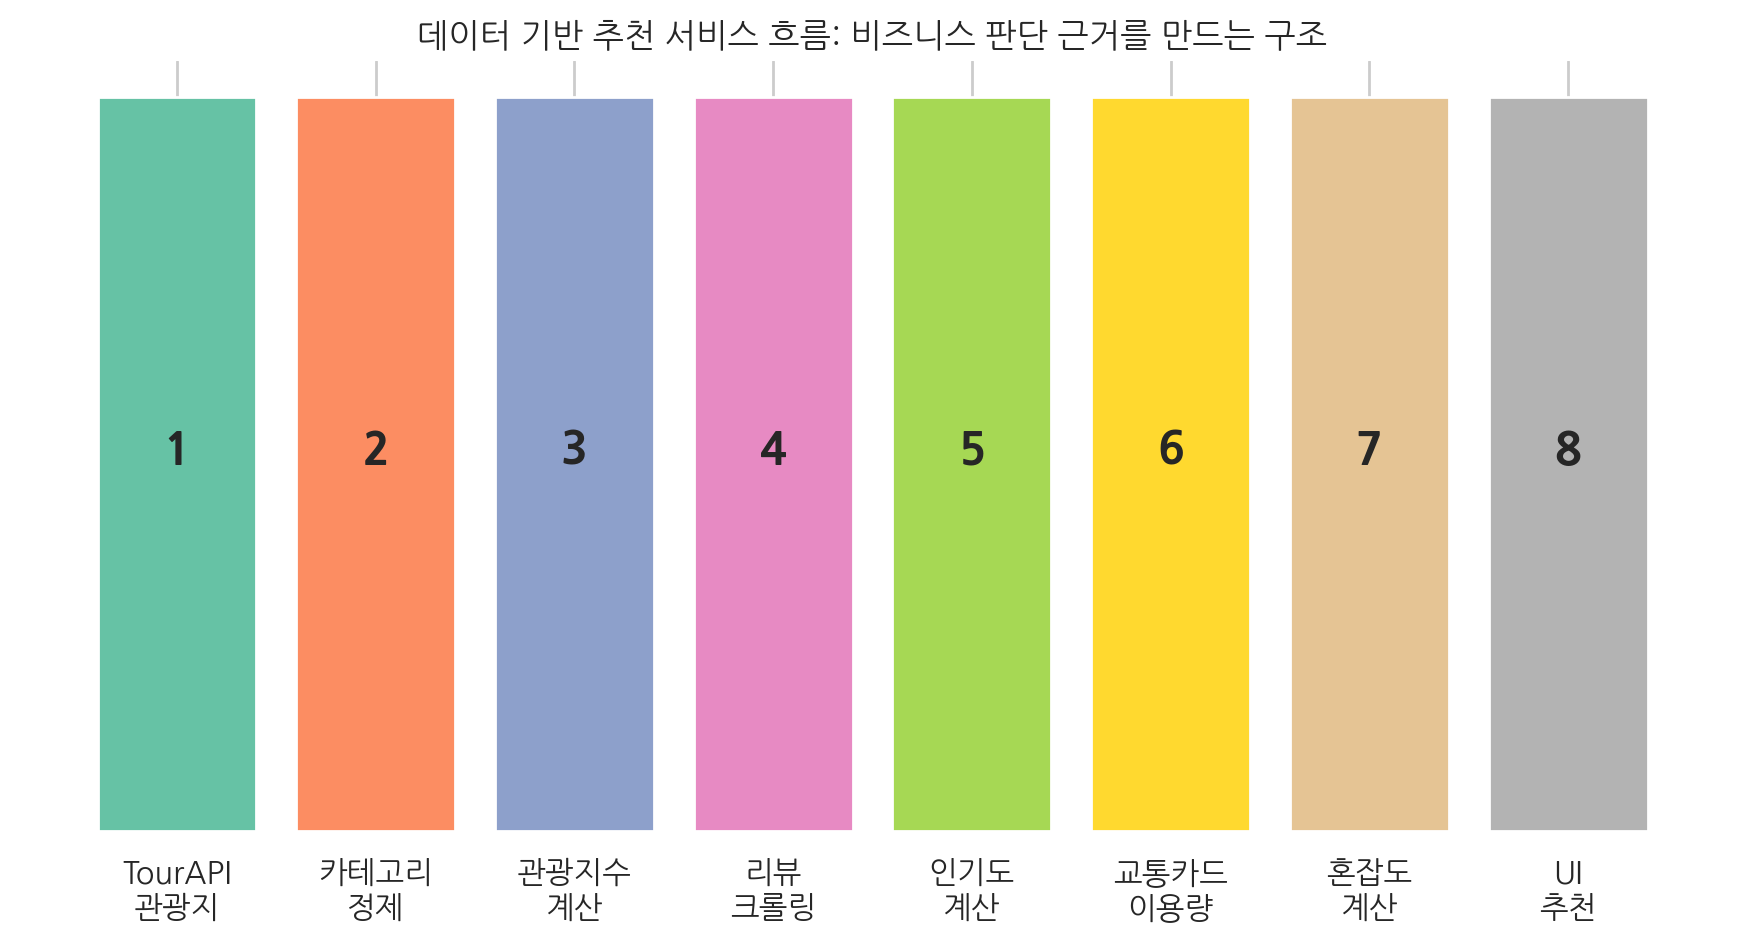

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
steps = ['TourAPI\n관광지', '카테고리\n정제', '관광지수\n계산', '리뷰\n크롤링', '인기도\n계산', '교통카드\n이용량', '혼잡도\n계산', 'UI\n추천']
colors = sns.color_palette('Set2', len(steps))
ax.bar(range(len(steps)), [1]*len(steps), color=colors)
ax.set_xticks(range(len(steps)))
ax.set_xticklabels(steps)
ax.set_yticks([])
ax.set_title('데이터 기반 추천 서비스 흐름: 비즈니스 판단 근거를 만드는 구조')
for i in range(len(steps)):
    ax.text(i, 0.52, str(i+1), ha='center', va='center', fontsize=16, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.show()
